## [1] Hierarchical Clustering dengan Dataset Sederhana

Pada tahap pertama dilakukan proses Hierarchical Clustering menggunakan
dataset sederhana yang terdiri dari enam data, yaitu a, b, c, d, e, dan f.
Setiap data memiliki dua nilai yang menunjukkan posisi data.

Pertama, beberapa library diimport untuk mendukung proses pengolahan
data, perhitungan jarak, Hierarchical Clustering, dan visualisasi.
NumPy digunakan untuk membuat dataset dalam bentuk array, Pandas
digunakan untuk menampilkan data dalam bentuk tabel, SciPy digunakan
untuk menghitung Euclidean Distance serta melakukan Hierarchical
Clustering, sedangkan Matplotlib digunakan untuk membuat grafik
dendrogram.

Selanjutnya dilakukan perhitungan Distance Matrix menggunakan
Euclidean Distance. Distance Matrix digunakan untuk mengetahui jarak
antara setiap pasangan data. Nilai jarak yang semakin kecil
menunjukkan bahwa data semakin dekat atau semakin mirip.

Setelah Distance Matrix diperoleh, proses Hierarchical Clustering
dilakukan menggunakan metode Single Linkage. Single Linkage menentukan
jarak antar-cluster berdasarkan jarak terdekat antara anggota dari
kedua cluster.

Hasil proses clustering kemudian divisualisasikan menggunakan
dendrogram. Dendrogram menunjukkan proses penggabungan data secara
bertahap berdasarkan jaraknya. Pada grafik, sumbu X menunjukkan data
yang digunakan, sedangkan sumbu Y menunjukkan jarak ketika data atau
cluster digabungkan.

Dengan demikian, tahap ini bertujuan untuk memahami proses dasar
Hierarchical Clustering mulai dari membuat dataset, menghitung jarak
antar-data, melakukan clustering menggunakan Single Linkage, hingga
menampilkan hasilnya dalam bentuk dendrogram.

=== Distance Matrix (Euclidean) ===
          a         b         c         d         e         f
a  0.000000  0.707107  5.656854  3.605551  4.242641  3.201562
b  0.707107  0.000000  4.949747  2.915476  3.535534  2.500000
c  5.656854  4.949747  0.000000  2.236068  1.414214  2.500000
d  3.605551  2.915476  2.236068  0.000000  1.000000  0.500000
e  4.242641  3.535534  1.414214  1.000000  0.000000  1.118034
f  3.201562  2.500000  2.500000  0.500000  1.118034  0.000000


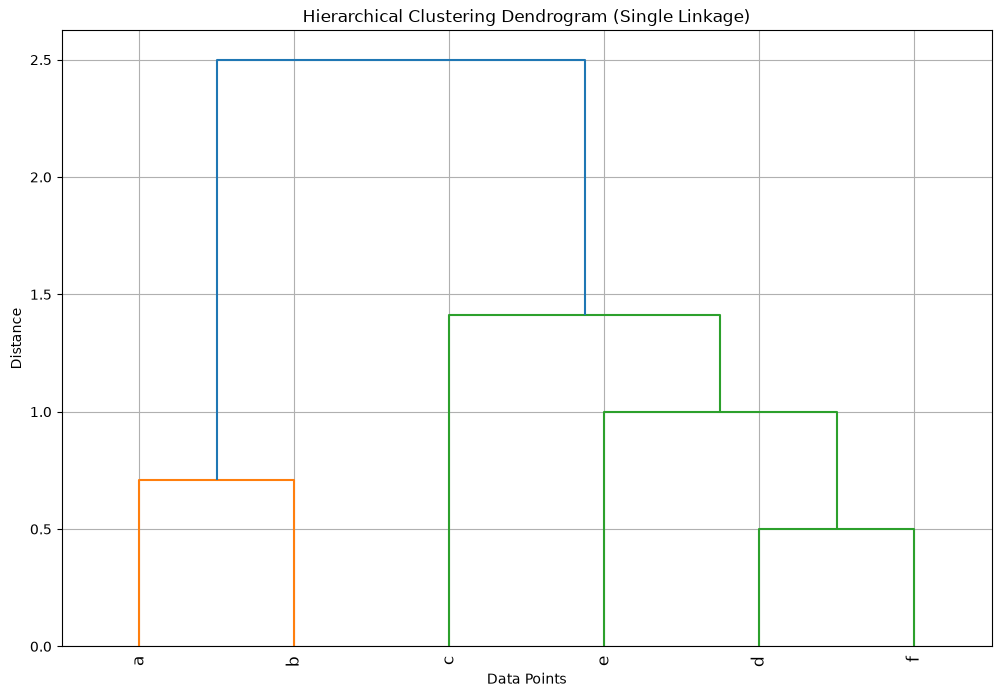

In [1]:
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
# 1. Dataset sederhana
data = np.array([
 [1.0, 1.0], # a
 [1.5, 1.5], # b
 [5.0, 5.0], # c
 [3.0, 4.0], # d
 [4.0, 4.0], # e
 [3.0, 3.5] # f
])
# 2. Hitung Distance Matrix (Euclidean Distance)
distance_matrix = pdist(data, metric='euclidean')
distance_df = pd.DataFrame(squareform(distance_matrix),
 columns=['a', 'b', 'c', 'd', 'e', 'f'],
 index=['a', 'b', 'c', 'd', 'e', 'f'])
# 3. Tampilkan Distance Matrix
print("=== Distance Matrix (Euclidean) ===")
print(distance_df)
# 4. Hierarchical Clustering (Single Linkage)
linked = linkage(data, method='single')
# 5. Plot Dendrogram
plt.figure(figsize=(12, 8))
plt.title("Hierarchical Clustering Dendrogram (Single Linkage)")
dendrogram(linked, labels=['a', 'b', 'c', 'd', 'e', 'f'], leaf_rotation=90)
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

## [2] Membaca Dataset Mall Customers

Pada tahap ini dataset Mall Customers dibaca menggunakan Pandas. Fungsi `head()` digunakan untuk menampilkan lima data pertama dan melihat struktur dataset.

In [2]:
import pandas as pd
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## [3] Memilih Fitur

Pada tahap ini dipilih dua fitur yang digunakan untuk clustering, yaitu Annual Income dan Spending Score. Kedua fitur tersebut disimpan dalam variabel `x`.

In [3]:
x = df.iloc[:, [3, 4]].values

## [4] Standardisasi Data

Pada tahap ini data distandardisasi menggunakan `StandardScaler` agar skala kedua fitur menjadi lebih sebanding sebelum dilakukan clustering.

In [4]:
from sklearn.preprocessing import StandardScaler
data_scaler = StandardScaler()
scaled_data = data_scaler.fit_transform(x)
scaled_data.shape

(200, 2)

## [5] Hierarchical Clustering

Pada tahap ini dilakukan Hierarchical Clustering menggunakan metode Complete Linkage dan Euclidean Distance. Hasil clustering disimpan dalam variabel `clustering`.

In [5]:
from scipy.cluster.hierarchy import linkage, dendrogram
clustering = linkage(scaled_data, method="complete", metric="euclidean")

## [6] Visualisasi Dendrogram

Pada tahap ini hasil Hierarchical Clustering ditampilkan dalam bentuk dendrogram untuk melihat proses pengelompokan data berdasarkan jaraknya.

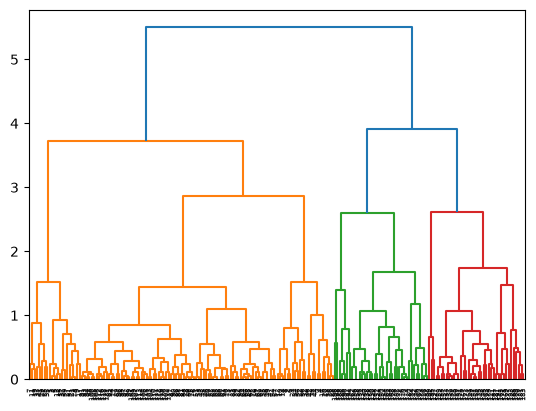

In [6]:
import matplotlib.pyplot as plt
dendrogram(clustering)
plt.show()

## Tugas


## Tugas: Perbandingan Linkage

Hasil dendrogram menunjukkan bahwa Single Linkage, Complete Linkage,
dan Average Linkage menghasilkan pola penggabungan cluster yang berbeda.
Single Linkage menggunakan jarak terdekat, Complete Linkage menggunakan
jarak terjauh, sedangkan Average Linkage menggunakan rata-rata jarak.

Pada dataset ini, data d dan f memiliki jarak paling kecil, yaitu 0.5,
sehingga menjadi pasangan yang bergabung terlebih dahulu. Perbedaan
metode linkage terlihat pada proses penggabungan cluster berikutnya.

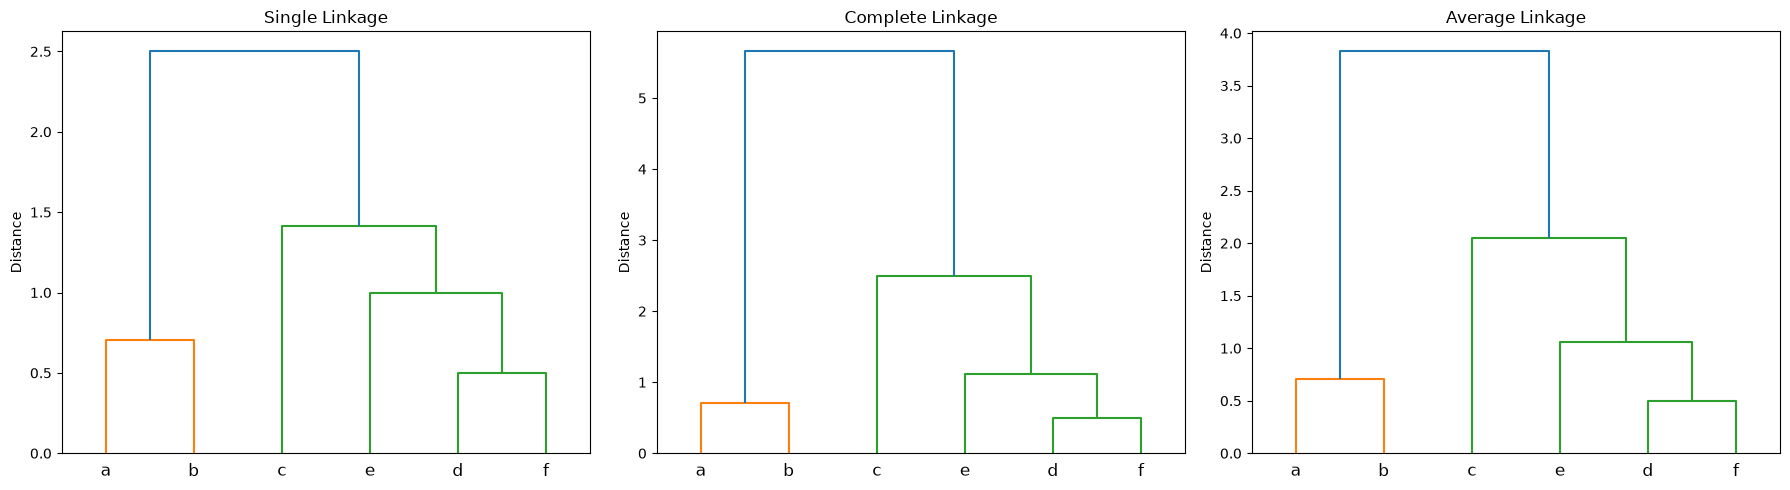

In [7]:
# Perbandingan Single, Complete, dan Average Linkage

linked_single = linkage(data, method='single')
linked_complete = linkage(data, method='complete')
linked_average = linkage(data, method='average')

plt.figure(figsize=(18, 5))

# Single Linkage
plt.subplot(1, 3, 1)
dendrogram(linked_single, labels=['a', 'b', 'c', 'd', 'e', 'f'])
plt.title("Single Linkage")
plt.ylabel("Distance")

# Complete Linkage
plt.subplot(1, 3, 2)
dendrogram(linked_complete, labels=['a', 'b', 'c', 'd', 'e', 'f'])
plt.title("Complete Linkage")
plt.ylabel("Distance")

# Average Linkage
plt.subplot(1, 3, 3)
dendrogram(linked_average, labels=['a', 'b', 'c', 'd', 'e', 'f'])
plt.title("Average Linkage")
plt.ylabel("Distance")

plt.tight_layout()
plt.show()